# Neuroevolución y Word Embeddings
- ### La neuroevolución es una técnica de inteligencia artificial que combina redes neuronales con algoritmos evolutivos.
- ### Optimiza automáticamente la estructura y parámetros de una red.

## Inspiración biológica:

- ### Se basa en la evolución natural (selección, mutación y recombinación).

- ### Las redes neuronales "evolucionan" para adaptarse a una tarea.

## Tipos principales:

- ### Evolución de pesos: Optimiza los parámetros: pesos y sesgos ($bias$) de una red fija.

- ### Evolución de topologías: Modifica la arquitectura de la red (Por ejemplo, el método NEAT).

## Ventajas:

- ### No requiere del cálculo de gradientes (útil para problemas no diferenciables).

- ### Explora múltiples soluciones en paralelo.

- ### Puede descubrir arquitecturas novedosas.

## Representación del texto: Word Embeddings

- ### **Word embeddings** son representaciones numéricas densas y continuas de palabras en un espacio vectorial.
- ### Estas representaciones capturan relaciones semánticas y sintácticas entre palabras.
- ### Palabras con significados similares están más cercanas en el espacio vectorial.
- ### Densidad: Cada palabra se representa como un vector en un espacio de dimensiones reducidas (por ejemplo, 100 o 300 dimensiones).
- ### Diferente a las representaciones como las matrices dispersas en el modelo de "bolsa de palabras".
- ### Similitud semántica: Las palabras con significados similares tendrán vectores cercanos en el espacio vectorial.
- ### Por ejemplo, en un buen modelo de embeddings, los vectores de "rey" y "reina" estarán cerca.
- ### Relaciones semánticas y aritmética vectorial:
- ### Se pueden realizar operaciones matemáticas que reflejan relaciones semánticas, como:
- ### **rey−hombre+mujer≈reina**


## Clasificación de Textos por medio de Neuroevolución y Word Embeddings

<img src="figs/fig-diagrama-clasificador2.png" width="900">

# Entrenar al clasificador

### Clasificador: Red Neuronal Multicapa
- #### Define una red con una arquitectura que consta de:
    - #### 2 datos de entrada ($x_1$, $x_2$)
    - #### capa 1 (4 neuronas)
    - #### capa 2 (3 neuronas)
    - #### capa 3 (2 neuronas): 2 datos de salida ($y_1$, $y_2$)

<center>
<img src="figs/fig-red_neuronal.png" width="800" style="background-color:white;">
</center>



- #### Número de parámetros de la red:
    - #### Pesos en la capa 1: $w_{ij}^{(1)}$ = 8 (2 entradas x 4 neuronas) y   4 sesgos ($bias$) (1 de cada neurona)
    - #### Pesos en la capa 2: $w_{ij}^{(2)}$ = 12 (4 entradas [4 neuronas de la capa 1] x 3 neuronas) y  3 sesgos ($bias$) (1 de cada neurona)
    - #### Pesos en la capa 3: $w_{ij}^{(3)}$ = 6 (3 entradas [3 neuronas de la capa 2] x 2 neuronas) y  2 sesgos ($bias$) (1 de cada neurona)
    - #### Total de parámetros: 35 (pesos y $bias$)



### 1. Cargar los datos

In [1]:
import pandas as pd
import numpy as np

# ─── Variables globales ───────────────────────────────────────────────────────
# Arquitectura: lista con el número de neuronas de cada capa oculta.
# Ejemplo: [128, 102] reproduce el comportamiento original (128 → ~102).
# Para más capas: [256, 128, 64], [512, 256, 128, 64], etc.
_CAPAS_OCULTAS    = [128, 102]   # <── modifica aquí para cambiar arquitectura
_N_CLASES         = 3
_TIPO_WORD_EMBEDDINGS = "we_ft"  # "we_ft" | "we_mx" | "we_es"

dataset = pd.read_json("./data/dataset_polaridad_es_train_embeddings.json", lines=True)
print("Total de ejemplos de entrenamiento")
print(dataset.klass.value_counts())
X = np.vstack(dataset[_TIPO_WORD_EMBEDDINGS].to_numpy())
Y = dataset['klass'].to_numpy()


Total de ejemplos de entrenamiento
klass
neutral     1485
positive     968
negative     689
Name: count, dtype: int64


### 2. Codificar las categorías (clases)

In [2]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
print("Clases:", le.classes_)
print("Clases codificadas:", le.transform(le.classes_))


Clases: ['negative' 'neutral' 'positive']
Clases codificadas: [0 1 2]


### 3. Preparar conjuntos de entrenamiento y validación

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_encoded, test_size=0.2, stratify=Y_encoded, random_state=42
)
Y_train = Y_train[:, np.newaxis]
Y_val   = Y_val[:, np.newaxis]
print(Y_train.shape, Y_val.shape)


(2513, 1) (629, 1)


### 4. Arquitectura de la red neuronal (configurable)

La clase `RedNeuronal` acepta **cualquier número de capas ocultas** mediante el parámetro `capas_ocultas: list[int]`. Internamente mantiene un índice de offsets (`info_capas`) que permite a los operadores genéticos actuar capa a capa en lugar de gen a gen.

In [4]:
from torch import nn
import torch
import numpy as np


class RedNeuronal(nn.Module):
    """
    Red neuronal completamente configurable.

    Parameters
    ----------
    tam_entrada : int
        Dimensión del vector de entrada (p. ej. tamaño del word embedding).
    capas_ocultas : list[int]
        Lista con el número de neuronas de cada capa oculta.
        Ejemplo: [128, 102] → dos capas ocultas.
    tam_salida : int
        Número de clases de salida.
    activacion : str
        Función de activación interna: "relu" | "tanh" | "sigmoid" | "leaky_relu".
    """

    def __init__(self, tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
        super().__init__()

        # ── Construcción dinámica de capas ───────────────────────────────────
        self.capas = nn.ModuleList()
        dims = [tam_entrada] + list(capas_ocultas) + [tam_salida]
        for i in range(len(dims) - 1):
            self.capas.append(nn.Linear(dims[i], dims[i + 1]))

        # ── Función de activación ────────────────────────────────────────────
        _activaciones = {
            "relu":       nn.ReLU(),
            "tanh":       nn.Tanh(),
            "sigmoid":    nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU(0.01),
        }
        self.activacion = _activaciones.get(activacion, nn.ReLU())
        self.softmax    = nn.Softmax(dim=1)

        # ── Metadatos del genoma ─────────────────────────────────────────────
        # Cada capa FC tiene (in * out) pesos + out bias.
        self.info_capas = []   # lista de dicts con offsets para cada capa
        offset = 0
        for fc in self.capas:
            n_pesos = fc.weight.numel()
            n_bias  = fc.bias.numel()
            self.info_capas.append({
                "fc":       fc,
                "n_pesos":  n_pesos,
                "n_bias":   n_bias,
                "off_w":    offset,              # inicio pesos en el genoma
                "off_b":    offset + n_pesos,    # inicio bias en el genoma
                "off_next": offset + n_pesos + n_bias,
                "shape_w":  tuple(fc.weight.shape),
            })
            offset += n_pesos + n_bias

        self.tam_individuo = offset

    def forward(self, X):
        out = X
        for i, fc in enumerate(self.capas[:-1]):   # todas menos la última
            out = self.activacion(fc(out))
        out = self.softmax(self.capas[-1](out))     # capa de salida
        return out


### 5. Algoritmo evolutivo generalizado

#### Cruza inteligente
Los operadores de cruza trabajan sobre **segmentos de capa** en lugar de puntos aleatorios en el vector plano. Modos disponibles:
- `capa_completa` – cada capa (pesos + bias) se hereda entera de p1 o p2
- `capa_pesos` – solo intercambia los pesos de cada capa
- `capa_bias` – solo intercambia los bias de cada capa
- `capa_mixta` – pesos y bias de cada capa se deciden independientemente
- `punto_entre_capas` – corte de un punto pero alineado en fronteras de capa
- `aritmetica` – combinación convexa de los dos padres
- `uniforme` – gen a gen (referencia clásica)

#### Mutación inteligente
Modos disponibles:
- `adaptativa` – sigmas diferentes para pesos y bias; recorre todos los genes
- `por_capa` – muta capas con probabilidad `tasa_capa`; dentro de cada capa se puede restringir a `pesos`, `bias` o `ambos`
- `capa_aleatoria` – perturba fuertemente una sola capa elegida al azar
- `gaussiana` – mutación clásica uniforme sobre todo el genoma


In [5]:
import torch
import random
import numpy as np
from multiprocessing import cpu_count
from sklearn.metrics import f1_score
from joblib import Parallel, delayed


# ════════════════════════════════════════════════════════════════════════════
#  UTILIDADES: codificación / decodificación del genoma
# ════════════════════════════════════════════════════════════════════════════

def red_desde_config(tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    """Crea una instancia de RedNeuronal con la configuración dada."""
    return RedNeuronal(tam_entrada, capas_ocultas, tam_salida, activacion)


def individuo_a_red(individuo, tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    """Decodifica un vector numpy y carga los pesos en una RedNeuronal."""
    red = red_desde_config(tam_entrada, capas_ocultas, tam_salida, activacion)
    with torch.no_grad():
        for info in red.info_capas:
            fc   = info["fc"]
            pesos = individuo[info["off_w"]:info["off_b"]].reshape(info["shape_w"])
            bias  = individuo[info["off_b"]:info["off_next"]]
            fc.weight.data = torch.tensor(pesos).float()
            fc.bias.data   = torch.tensor(bias).float()
    return red


def red_a_individuo(red):
    """Serializa los pesos de una RedNeuronal en un vector numpy."""
    partes = []
    with torch.no_grad():
        for info in red.info_capas:
            partes.append(info["fc"].weight.detach().numpy().flatten())
            partes.append(info["fc"].bias.detach().numpy().flatten())
    return np.concatenate(partes)


# ════════════════════════════════════════════════════════════════════════════
#  INICIALIZACIÓN DE POBLACIÓN
# ════════════════════════════════════════════════════════════════════════════

def inicializar_poblacion(tam_poblacion, tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    """Inicialización uniforme U(-0.5, 0.5)."""
    red = red_desde_config(tam_entrada, capas_ocultas, tam_salida, activacion)
    return np.random.uniform(-0.5, 0.5, size=(tam_poblacion, red.tam_individuo))


def inicializar_poblacion_xavier(tam_poblacion, tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    """Inicialización Xavier para mejor convergencia."""
    poblacion = []
    for _ in range(tam_poblacion):
        red = red_desde_config(tam_entrada, capas_ocultas, tam_salida, activacion)
        with torch.no_grad():
            for info in red.info_capas:
                nn.init.xavier_normal_(info["fc"].weight)
                nn.init.zeros_(info["fc"].bias)
        poblacion.append(red_a_individuo(red))
    poblacion = np.array(poblacion)
    print(f"Población inicializada (Xavier): {poblacion.shape}")
    return poblacion


# ════════════════════════════════════════════════════════════════════════════
#  FITNESS
# ════════════════════════════════════════════════════════════════════════════

def funcion_fitness(individuo, X, Y, tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    red = individuo_a_red(individuo, tam_entrada, capas_ocultas, tam_salida, activacion)
    X_t = torch.tensor(X).float()
    with torch.no_grad():
        y_pred = torch.argmax(red(X_t), dim=1)
    return f1_score(Y, y_pred, average="macro")


def evaluar_fitness(poblacion, X, Y, tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    return np.array([
        funcion_fitness(ind, X, Y, tam_entrada, capas_ocultas, tam_salida, activacion)
        for ind in poblacion
    ])


def evaluar_fitness_paralelo(poblacion, X, Y, tam_entrada, capas_ocultas, tam_salida,
                              activacion="relu", n_jobs=-1):
    n_jobs = cpu_count() if n_jobs == -1 else n_jobs
    resultados = Parallel(n_jobs=n_jobs - 1, timeout=300, verbose=5)(
        delayed(funcion_fitness)(ind, X, Y, tam_entrada, capas_ocultas, tam_salida, activacion)
        for ind in poblacion
    )
    return np.array(resultados)


# ════════════════════════════════════════════════════════════════════════════
#  SELECCIÓN
# ════════════════════════════════════════════════════════════════════════════

def seleccionar_padres(poblacion, aptitudes, k=5):
    """Selección por torneo (k participantes)."""
    torneo = random.sample(list(zip(poblacion, aptitudes)), k=k)
    torneo.sort(key=lambda x: x[1], reverse=True)
    return torneo[0][0], torneo[1][0]


def elitismo(poblacion, fitness, tam_elite=2):
    """Devuelve los `tam_elite` mejores individuos."""
    idx = np.argsort(fitness)[::-1]
    return [poblacion[i] for i in idx[:tam_elite]]


# ════════════════════════════════════════════════════════════════════════════
#  OPERADORES DE CRUZA INTELIGENTE
# ════════════════════════════════════════════════════════════════════════════

def _get_info_capas(tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    """Devuelve info_capas de una red de referencia (para conocer offsets)."""
    return red_desde_config(tam_entrada, capas_ocultas, tam_salida, activacion).info_capas


def cruzar_por_capa(padre1, padre2, info_capas, modo="completa"):
    """
    Cruza a nivel de CAPA en lugar de a nivel de gen individual.

    Modos
    -----
    "completa"   : cada capa (pesos + bias juntos) se hereda entera de p1 o p2.
    "solo_pesos" : solo los pesos de cada capa se intercambian; bias del padre1.
    "solo_bias"  : solo los bias de cada capa se intercambian; pesos del padre1.
    "mixta"      : pesos de una capa y bias de otra (completamente aleatorio).
    """
    hijo1 = padre1.copy()
    hijo2 = padre2.copy()

    for info in info_capas:
        ow, ob, on = info["off_w"], info["off_b"], info["off_next"]
        intercambiar_pesos = random.random() < 0.5
        intercambiar_bias  = random.random() < 0.5

        if modo == "completa":
            if random.random() < 0.5:   # intercambiar toda la capa
                hijo1[ow:on], hijo2[ow:on] = padre2[ow:on].copy(), padre1[ow:on].copy()

        elif modo == "solo_pesos":
            if intercambiar_pesos:
                hijo1[ow:ob], hijo2[ow:ob] = padre2[ow:ob].copy(), padre1[ow:ob].copy()

        elif modo == "solo_bias":
            if intercambiar_bias:
                hijo1[ob:on], hijo2[ob:on] = padre2[ob:on].copy(), padre1[ob:on].copy()

        elif modo == "mixta":
            if intercambiar_pesos:
                hijo1[ow:ob], hijo2[ow:ob] = padre2[ow:ob].copy(), padre1[ow:ob].copy()
            if intercambiar_bias:
                hijo1[ob:on], hijo2[ob:on] = padre2[ob:on].copy(), padre1[ob:on].copy()

    return hijo1, hijo2


def cruzar_punto_por_capa(padre1, padre2, info_capas):
    """
    Cruza de UN PUNTO pero respetando fronteras de capa:
    el punto de corte cae siempre entre capas, nunca en medio de una.
    """
    n_capas = len(info_capas)
    # Punto de corte entre capa k y k+1  (puede ser 0 = todo p2, n = todo p1)
    k = random.randint(0, n_capas)
    if k == 0:
        return padre2.copy(), padre1.copy()
    if k == n_capas:
        return padre1.copy(), padre2.copy()

    corte = info_capas[k]["off_w"]   # inicio de la capa k+1
    hijo1 = np.concatenate([padre1[:corte], padre2[corte:]])
    hijo2 = np.concatenate([padre2[:corte], padre1[corte:]])
    return hijo1, hijo2


def cruzar_uniforme(padre1, padre2, prob=0.5):
    """Cruza uniforme clásica gen a gen (referencia)."""
    mascara = np.random.random(len(padre1)) < prob
    return np.where(mascara, padre2, padre1), np.where(mascara, padre1, padre2)


def cruzar_aritmetica(padre1, padre2, alpha=None):
    """
    Cruza aritmética (blend): hijo = alpha*p1 + (1-alpha)*p2.
    Si alpha=None se samplea U(0,1) por hijo.
    """
    a = random.random() if alpha is None else alpha
    return a * padre1 + (1 - a) * padre2, (1 - a) * padre1 + a * padre2


# Alias conveniente para usar desde el loop evolutivo
CRUZAS = {
    "capa_completa":     lambda p1, p2, ic: cruzar_por_capa(p1, p2, ic, "completa"),
    "capa_pesos":        lambda p1, p2, ic: cruzar_por_capa(p1, p2, ic, "solo_pesos"),
    "capa_bias":         lambda p1, p2, ic: cruzar_por_capa(p1, p2, ic, "solo_bias"),
    "capa_mixta":        lambda p1, p2, ic: cruzar_por_capa(p1, p2, ic, "mixta"),
    "punto_entre_capas": lambda p1, p2, ic: cruzar_punto_por_capa(p1, p2, ic),
    "uniforme":          lambda p1, p2, ic: cruzar_uniforme(p1, p2),       # ic no usada
    "aritmetica":        lambda p1, p2, ic: cruzar_aritmetica(p1, p2),     # ic no usada
}


# ════════════════════════════════════════════════════════════════════════════
#  OPERADORES DE MUTACIÓN INTELIGENTE
# ════════════════════════════════════════════════════════════════════════════

def mutar_gaussiana(individuo, tasa=0.1, sigma=0.1):
    """Mutación gaussiana estándar (referencia)."""
    ind = individuo.copy()
    mascara = np.random.rand(len(ind)) < tasa
    ind[mascara] += np.random.normal(0, sigma, mascara.sum())
    return ind


def mutar_por_capa(individuo, info_capas, tasa_capa=0.5,
                   tasa_gen=0.1, sigma=0.1,
                   objetivo="ambos"):
    """
    Mutación estructurada que actúa capa a capa.

    Parameters
    ----------
    tasa_capa : float
        Probabilidad de que UNA capa sea mutada.
    tasa_gen  : float
        Probabilidad de mutar cada gen dentro de una capa seleccionada.
    sigma     : float
        Desviación estándar del ruido gaussiano.
    objetivo  : str
        Qué parte de cada capa se muta: "pesos" | "bias" | "ambos".
    """
    ind = individuo.copy()
    for info in info_capas:
        if random.random() > tasa_capa:
            continue  # esta capa no se muta

        ow, ob, on = info["off_w"], info["off_b"], info["off_next"]

        if objetivo in ("pesos", "ambos"):
            m = np.random.rand(ob - ow) < tasa_gen
            ind[ow:ob][m] += np.random.normal(0, sigma, m.sum())

        if objetivo in ("bias", "ambos"):
            m = np.random.rand(on - ob) < tasa_gen
            ind[ob:on][m] += np.random.normal(0, sigma, m.sum())

    return ind


def mutar_capa_aleatoria(individuo, info_capas, sigma=0.1, objetivo="ambos"):
    """
    Muta COMPLETAMENTE una única capa elegida al azar (mutación de alta intensidad localizada).
    """
    ind  = individuo.copy()
    info = random.choice(info_capas)
    ow, ob, on = info["off_w"], info["off_b"], info["off_next"]

    if objetivo in ("pesos", "ambos"):
        ind[ow:ob] += np.random.normal(0, sigma, ob - ow)
    if objetivo in ("bias", "ambos"):
        ind[ob:on] += np.random.normal(0, sigma, on - ob)
    return ind


def mutar_adaptativa(individuo, info_capas, tasa_gen=0.1,
                     sigma_pesos=0.1, sigma_bias=0.3):
    """
    Mutación con sigmas diferentes para pesos (mayor impacto) y bias (menor).
    Recorre todas las capas pero con probabilidad tasa_gen por gen.
    """
    ind = individuo.copy()
    for info in info_capas:
        ow, ob, on = info["off_w"], info["off_b"], info["off_next"]
        m_w = np.random.rand(ob - ow) < tasa_gen
        m_b = np.random.rand(on - ob) < tasa_gen
        ind[ow:ob][m_w] += np.random.normal(0, sigma_pesos, m_w.sum())
        ind[ob:on][m_b] += np.random.normal(0, sigma_bias,  m_b.sum())
    return ind


# Alias conveniente — cada lambda filtra solo los parámetros que su función acepta
MUTACIONES = {
    "gaussiana":      lambda ind, ic, **kw: mutar_gaussiana(
                          ind,
                          tasa=kw.get("tasa_gen", 0.1),
                          sigma=kw.get("sigma_pesos", 0.1)),
    "por_capa":       lambda ind, ic, **kw: mutar_por_capa(
                          ind, ic,
                          tasa_capa=kw.get("tasa_capa", 0.5),
                          tasa_gen=kw.get("tasa_gen", 0.1),
                          sigma=kw.get("sigma_pesos", 0.1)),
    "capa_aleatoria": lambda ind, ic, **kw: mutar_capa_aleatoria(
                          ind, ic,
                          sigma=kw.get("sigma_pesos", 0.1)),
    "adaptativa":     lambda ind, ic, **kw: mutar_adaptativa(
                          ind, ic,
                          tasa_gen=kw.get("tasa_gen", 0.1),
                          sigma_pesos=kw.get("sigma_pesos", 0.1),
                          sigma_bias=kw.get("sigma_bias", 0.3)),
}


# ════════════════════════════════════════════════════════════════════════════
#  ALGORITMO EVOLUTIVO GENERALIZADO
# ════════════════════════════════════════════════════════════════════════════

def algoritmo_evolutivo(
    X, Y, X_val, Y_val,
    capas_ocultas,              # ← arquitectura dinámica
    tam_salida,
    activacion      = "relu",
    tam_poblacion   = 30,
    num_generaciones= 50,
    tipo_cruza      = "capa_mixta",    # clave de CRUZAS
    tipo_mutacion   = "adaptativa",    # clave de MUTACIONES
    tasa_capa       = 0.6,
    tasa_gen        = 0.1,
    sigma_pesos     = 0.1,
    sigma_bias      = 0.3,
    tam_elite       = 10,
    init            = "uniforme",      # "uniforme" | "xavier"
    run_paralelo    = False,
):
    tam_entrada = X.shape[1]
    info_capas  = _get_info_capas(tam_entrada, capas_ocultas, tam_salida, activacion)

    print(f"Arquitectura: {tam_entrada} → {capas_ocultas} → {tam_salida}")
    print(f"Tamaño del genoma: {info_capas[-1]['off_next']} genes")
    print(f"Cruza: {tipo_cruza} | Mutación: {tipo_mutacion}")

    # Inicialización
    if init == "xavier":
        poblacion = inicializar_poblacion_xavier(tam_poblacion, tam_entrada, capas_ocultas, tam_salida, activacion)
    else:
        poblacion = inicializar_poblacion(tam_poblacion, tam_entrada, capas_ocultas, tam_salida, activacion)

    fn_cruza   = CRUZAS[tipo_cruza]
    fn_mutacion = MUTACIONES[tipo_mutacion]
    kw_mut = dict(tasa_capa=tasa_capa, tasa_gen=tasa_gen,
                  sigma_pesos=sigma_pesos, sigma_bias=sigma_bias,
                  sigma=sigma_pesos)   # para mutaciones que usen "sigma"

    best_fitness_hist = []
    mean_fitness_hist = []

    for gen in range(num_generaciones):
        # ── Evaluación ───────────────────────────────────────────────────────
        if run_paralelo:
            val_fitness = evaluar_fitness_paralelo(
                poblacion, X, Y, tam_entrada, capas_ocultas, tam_salida, activacion)
        else:
            val_fitness = evaluar_fitness(
                poblacion, X, Y, tam_entrada, capas_ocultas, tam_salida, activacion)

        best = np.max(val_fitness)
        mean = np.mean(val_fitness)
        best_fitness_hist.append(best)
        mean_fitness_hist.append(mean)
        print(f"Gen {gen+1:3d}/{num_generaciones} | Mejor={best:.4f} | Promedio={mean:.4f}")

        # ── Elitismo ─────────────────────────────────────────────────────────
        elites = elitismo(poblacion, val_fitness, tam_elite)

        # ── Reproducción ────────────────────────────────────────────────────
        nueva_poblacion = []
        while len(nueva_poblacion) < tam_poblacion - tam_elite:
            p1, p2 = seleccionar_padres(poblacion, val_fitness)
            h1, h2 = fn_cruza(p1, p2, info_capas)
            h1 = fn_mutacion(h1, info_capas, **kw_mut)
            h2 = fn_mutacion(h2, info_capas, **kw_mut)
            nueva_poblacion.append(h1)
            if len(nueva_poblacion) < tam_poblacion - tam_elite:
                nueva_poblacion.append(h2)

        # ── Nueva generación = élites + hijos ────────────────────────────────
        poblacion = np.array(elites + nueva_poblacion)

    # ── Evaluación final y resultado ─────────────────────────────────────────
    val_fitness = evaluar_fitness(poblacion, X, Y, tam_entrada, capas_ocultas, tam_salida, activacion)
    best_ind    = poblacion[np.argmax(val_fitness)]
    test_f1     = funcion_fitness(best_ind, X_val, Y_val, tam_entrada, capas_ocultas, tam_salida, activacion)
    print(f"\nF1-score en validación: {test_f1:.4f}")

    return best_ind, best_fitness_hist, mean_fitness_hist


def predecir_clase(individuo, X, tam_entrada, capas_ocultas, tam_salida, activacion="relu"):
    red = individuo_a_red(individuo, tam_entrada, capas_ocultas, tam_salida, activacion)
    X_t = torch.from_numpy(X).float()
    with torch.no_grad():
        return torch.argmax(red(X_t), dim=1)


### 6. Ejecución del algoritmo evolutivo

In [6]:
# ─── Parámetros del experimento ──────────────────────────────────────────────
# Cambia _CAPAS_OCULTAS al inicio del notebook para usar otra arquitectura.
# Ejemplos:
#   [128, 102]        → original (2 capas ocultas)
#   [256, 128, 64]    → más profunda
#   [512]             → más ancha y menos profunda
#   [64, 64, 64, 64]  → 4 capas iguales

best_individuo, hist_best, hist_mean = algoritmo_evolutivo(
    X_train, Y_train, X_val, Y_val,
    capas_ocultas      = _CAPAS_OCULTAS,
    tam_salida         = _N_CLASES,
    activacion         = "relu",
    tam_poblacion      = 50,
    num_generaciones   = 50,
    tipo_cruza         = "capa_mixta",   # prueba: "capa_completa", "punto_entre_capas", "aritmetica"
    tipo_mutacion      = "adaptativa",   # prueba: "gaussiana", "por_capa", "capa_aleatoria"
    tasa_capa          = 0.6,
    tasa_gen           = 0.1,
    sigma_pesos        = 0.1,
    sigma_bias         = 0.3,
    tam_elite          = 10,
    init               = "uniforme",     # "uniforme" | "xavier"
    run_paralelo       = False,
)


Arquitectura: 300 → [128, 102] → 3
Tamaño del genoma: 51995 genes
Cruza: capa_mixta | Mutación: adaptativa
Gen   1/50 | Mejor=0.3506 | Promedio=0.1971
Gen   2/50 | Mejor=0.3506 | Promedio=0.2284
Gen   3/50 | Mejor=0.3506 | Promedio=0.2283
Gen   4/50 | Mejor=0.3506 | Promedio=0.2258
Gen   5/50 | Mejor=0.3506 | Promedio=0.2359
Gen   6/50 | Mejor=0.3506 | Promedio=0.2357
Gen   7/50 | Mejor=0.3506 | Promedio=0.2347
Gen   8/50 | Mejor=0.3676 | Promedio=0.2495
Gen   9/50 | Mejor=0.3676 | Promedio=0.2476
Gen  10/50 | Mejor=0.3676 | Promedio=0.2500
Gen  11/50 | Mejor=0.3893 | Promedio=0.2520
Gen  12/50 | Mejor=0.3893 | Promedio=0.2440
Gen  13/50 | Mejor=0.3893 | Promedio=0.2368
Gen  14/50 | Mejor=0.4000 | Promedio=0.2357
Gen  15/50 | Mejor=0.4000 | Promedio=0.2508
Gen  16/50 | Mejor=0.4000 | Promedio=0.2495
Gen  17/50 | Mejor=0.4000 | Promedio=0.2589
Gen  18/50 | Mejor=0.4000 | Promedio=0.2527
Gen  19/50 | Mejor=0.4000 | Promedio=0.2564
Gen  20/50 | Mejor=0.4000 | Promedio=0.2554
Gen  21/50 | 

### 7. Convergencia

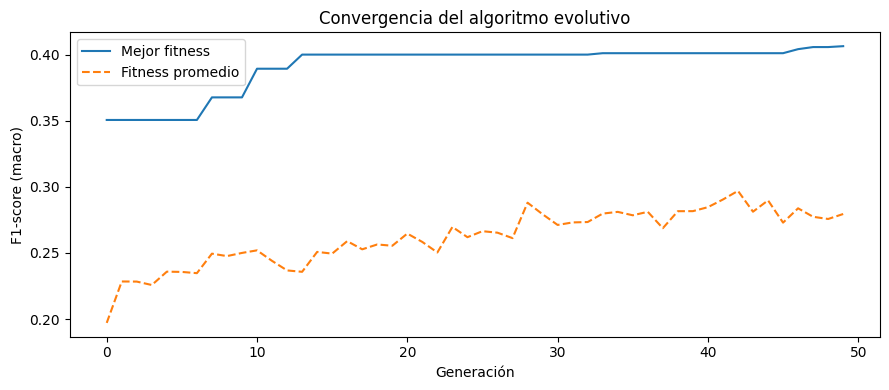

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(hist_best,  label="Mejor fitness")
plt.plot(hist_mean,  label="Fitness promedio", linestyle="--")
plt.xlabel("Generación")
plt.ylabel("F1-score (macro)")
plt.title("Convergencia del algoritmo evolutivo")
plt.legend()
plt.tight_layout()
plt.show()


### 8. Evaluación en el conjunto de test

In [8]:
import numpy as np, pandas as pd
from sklearn.metrics import f1_score, classification_report

tam_entrada = X_train.shape[1]

dataset_test = pd.read_json("./data/dataset_polaridad_es_test_embeddings.json", lines=True)
print("Total de ejemplos de test")
print(dataset_test.klass.value_counts())
X_test = np.vstack(dataset_test[_TIPO_WORD_EMBEDDINGS].to_numpy())
Y_test = le.transform(dataset_test['klass'].to_numpy())
Y_t    = Y_test[:, np.newaxis]

y_pred_test = predecir_clase(best_individuo, X_test,
                             tam_entrada, _CAPAS_OCULTAS, _N_CLASES)

score = f1_score(Y_t, y_pred_test, average="macro")
print(f"F1-score en test: {score:.4f}")
print()
print(classification_report(Y_t, y_pred_test, target_names=le.classes_))


Total de ejemplos de test
klass
neutral     371
positive    242
negative    173
Name: count, dtype: int64
F1-score en test: 0.3738

              precision    recall  f1-score   support

    negative       0.30      0.13      0.18       173
     neutral       0.52      0.62      0.57       371
    positive       0.35      0.40      0.37       242

    accuracy                           0.44       786
   macro avg       0.39      0.38      0.37       786
weighted avg       0.42      0.44      0.42       786



# Ejercicio 1
### Comparar tipos de word embeddings y operadores de variación
- `we_ft`, `we_mx`, `we_es`
- Distintos operadores de cruza y mutación
- Diferentes tamaños de población y número de generaciones

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# Ejercicio 1 – Comparar operadores y tipos de word embeddings
# ════════════════════════════════════════════════════════════════════════════

# Ejemplo: probar todos los tipos de cruza con la misma configuración base
resultados = {}
for tipo_cruza in ["capa_completa", "capa_mixta", "punto_entre_capas", "aritmetica"]:
    print(f"\n{'='*60}")
    print(f"Cruza: {tipo_cruza}")
    ind, hb, hm = algoritmo_evolutivo(
        X_train, Y_train, X_val, Y_val,
        capas_ocultas    = _CAPAS_OCULTAS,
        tam_salida       = _N_CLASES,
        tam_poblacion    = 30,
        num_generaciones = 20,
        tipo_cruza       = tipo_cruza,
        tipo_mutacion    = "adaptativa",
    )
    resultados[tipo_cruza] = max(hb)
    print(f"  Mejor F1 validación: {max(hb):.4f}")

print("\nResumen:")
for k, v in sorted(resultados.items(), key=lambda x: -x[1]):
    print(f"  {k:25s}: {v:.4f}")



Cruza: capa_completa
Arquitectura: 300 → [128, 102] → 3
Tamaño del genoma: 51995 genes
Cruza: capa_completa | Mutación: adaptativa
Gen   1/20 | Mejor=0.3089 | Promedio=0.1931
Gen   2/20 | Mejor=0.3739 | Promedio=0.2231
Gen   3/20 | Mejor=0.4149 | Promedio=0.2402
Gen   4/20 | Mejor=0.4149 | Promedio=0.2543
Gen   5/20 | Mejor=0.4149 | Promedio=0.2591
Gen   6/20 | Mejor=0.4149 | Promedio=0.2752
Gen   7/20 | Mejor=0.4149 | Promedio=0.2912
Gen   8/20 | Mejor=0.4149 | Promedio=0.2851
Gen   9/20 | Mejor=0.4149 | Promedio=0.2911
Gen  10/20 | Mejor=0.4149 | Promedio=0.2900
Gen  11/20 | Mejor=0.4149 | Promedio=0.2950
Gen  12/20 | Mejor=0.4149 | Promedio=0.2859
Gen  13/20 | Mejor=0.4149 | Promedio=0.2967
Gen  14/20 | Mejor=0.4149 | Promedio=0.3180
Gen  15/20 | Mejor=0.4149 | Promedio=0.3026
Gen  16/20 | Mejor=0.4149 | Promedio=0.3059
Gen  17/20 | Mejor=0.4149 | Promedio=0.3198
Gen  18/20 | Mejor=0.4149 | Promedio=0.3003
Gen  19/20 | Mejor=0.4149 | Promedio=0.3203
Gen  20/20 | Mejor=0.4149 | Prom

# Ejercicio 2
### Comparar arquitecturas de red neuronal
Modifica `_CAPAS_OCULTAS` o usa el bloque de abajo para comparar varias en un solo barrido.

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# Ejercicio 2 – Probar diferentes arquitecturas de red
# ════════════════════════════════════════════════════════════════════════════

arquitecturas = {
    "original  [128, 102]":  [128, 102],
    "profunda  [256,128,64]": [256, 128, 64],
    "ancha     [512]":        [512],
    "4 capas   [64,64,64,64]":[64, 64, 64, 64],
}

resultados_arq = {}
for nombre, capas in arquitecturas.items():
    print(f"\n{'='*60}")
    print(f"Arquitectura: {nombre}")
    ind, hb, hm = algoritmo_evolutivo(
        X_train, Y_train, X_val, Y_val,
        capas_ocultas    = capas,
        tam_salida       = _N_CLASES,
        tam_poblacion    = 30,
        num_generaciones = 20,
        tipo_cruza       = "capa_mixta",
        tipo_mutacion    = "adaptativa",
    )
    resultados_arq[nombre] = max(hb)
    print(f"  Mejor F1 validación: {max(hb):.4f}")

print("\nResumen:")
for k, v in sorted(resultados_arq.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.4f}")



Arquitectura: original  [128, 102]
Arquitectura: 300 → [128, 102] → 3
Tamaño del genoma: 51995 genes
Cruza: capa_mixta | Mutación: adaptativa
Gen   1/20 | Mejor=0.3278 | Promedio=0.1982
Gen   2/20 | Mejor=0.3278 | Promedio=0.2359
Gen   3/20 | Mejor=0.3385 | Promedio=0.2441
Gen   4/20 | Mejor=0.3385 | Promedio=0.2473
Gen   5/20 | Mejor=0.3385 | Promedio=0.2504
Gen   6/20 | Mejor=0.3385 | Promedio=0.2451
Gen   7/20 | Mejor=0.3411 | Promedio=0.2705
Gen   8/20 | Mejor=0.3652 | Promedio=0.2783
Gen   9/20 | Mejor=0.3652 | Promedio=0.2622
Gen  10/20 | Mejor=0.3734 | Promedio=0.2925
Gen  11/20 | Mejor=0.3734 | Promedio=0.2801
Gen  12/20 | Mejor=0.3734 | Promedio=0.2937
Gen  13/20 | Mejor=0.3734 | Promedio=0.2922
Gen  14/20 | Mejor=0.3734 | Promedio=0.2771
Gen  15/20 | Mejor=0.3734 | Promedio=0.2948
Gen  16/20 | Mejor=0.3734 | Promedio=0.2960
Gen  17/20 | Mejor=0.3734 | Promedio=0.2998
Gen  18/20 | Mejor=0.3734 | Promedio=0.2752
Gen  19/20 | Mejor=0.3747 | Promedio=0.3057
Gen  20/20 | Mejor=0.